# Hands On Lab — Feature Engineering & Hyperparameter Tuning

**Week 4 — Day 4 | BinX Tech AI & ML Internship**

---

## Objective

In the learning notebook, I explored feature engineering and
hyperparameter tuning on the Pima Diabetes dataset.

In this lab, I apply the same ideas to a new dataset:
**Student Performance**.

The workflow is:

1. Establish a baseline model
2. Engineer and test new features
3. Compare each feature using 5-fold cross-validation
4. Tune the Random Forest with GridSearchCV
5. Analyze the best features and hyperparameters
6. Evaluate the final model once on the locked test set

**Dataset:** Student Performance — 2,392 students  
**Task:** 5-class GradeClass prediction  
**Model:** Random Forest Classifier

---

## Step 1 — Import Libraries

In [111]:
import pandas as pd
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

SEED = 42

## Step 2 — Load & Verify the Data

I worked with this dataset in Days 1–3, so I do not repeat the
full EDA here.

I only verify the dataset shape, target distribution, and missing
values before starting the experiments.

In [112]:
# Load the Student Performance dataset
df = pd.read_csv(
    "../../Week1/mini_project/Data/Student_performance_data _.csv"
)

# StudentID is only an identifier, not a predictive feature
df = df.drop(columns=["StudentID"])


# Separate features (X) from the target (y)
X = df.drop(columns=["GradeClass"])
y = df["GradeClass"].astype(int)


# Basic verification
print(f"Dataset shape: {df.shape}")
print(f"Number of features: {X.shape[1]}")

print("\nTarget distribution:")
dist = y.value_counts().sort_index()

for grade, count in dist.items():
    label = ["A", "B", "C", "D", "F"][grade]
    print(
        f"  Class {grade} ({label}): "
        f"{count} students ({count / len(y):.1%})"
    )

# Check whether any missing values exist
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Dataset shape: (2392, 14)
Number of features: 13

Target distribution:
  Class 0 (A): 107 students (4.5%)
  Class 1 (B): 269 students (11.2%)
  Class 2 (C): 391 students (16.3%)
  Class 3 (D): 414 students (17.3%)
  Class 4 (F): 1211 students (50.6%)

Total missing values: 0


## Step 3 — Three-Way Split

Same discipline from Day 1: the test set is locked immediately.

The training set is used for feature experiments and
GridSearchCV. The validation set remains available for
development, while the final test set stays untouched until
the end.

In [113]:
# Step 1: Lock the final test set

# The test set will remain untouched until the final evaluation.
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)


# Step 2: Split the remaining 80%

# 25% of the remaining 80% = 20% of the full dataset.
# This gives us:
# 60% training + 20% validation + 20% test.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=SEED,
    stratify=y_temp
)


# Step 3: Create 5-fold stratified CV

# The same CV strategy will be used for all experiments
# so that the comparisons are fair.
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)


# Check the resulting sizes
print(f"Training:   {X_tr.shape[0]} rows  (60%)")
print(f"Validation: {X_val.shape[0]} rows  (20%)")
print(f"Test:       {X_test.shape[0]} rows  (20%)")

Training:   1434 rows  (60%)
Validation: 479 rows  (20%)
Test:       479 rows  (20%)


## Step 4 — Establish the Baseline

Before engineering any features or tuning hyperparameters,
I need a reference point.

The baseline is an untuned Random Forest using the original
features.

Every experiment will be compared against this reference
using the same 5-fold cross-validation setup.

In [114]:
# Baseline Random Forest

# This model uses the original features and default
# hyperparameters that we chose for the baseline.
baseline_model = RandomForestClassifier(
    n_estimators=100,
    random_state=SEED
)


# Evaluate the baseline using the same 5-fold CV
# that will be used for all later experiments.
baseline_scores = cross_val_score(
    baseline_model,
    X_tr,
    y_tr,
    cv=skf,
    scoring="f1_weighted"
)


# Store the mean CV score as our reference point.
baseline_mean = baseline_scores.mean()


print(
    f"Baseline CV Weighted F1: "
    f"{baseline_mean:.3f} ± {baseline_scores.std():.3f}"
)

print(
    "\nThis is the benchmark for the feature engineering experiments."
)

Baseline CV Weighted F1: 0.918 ± 0.006

This is the benchmark for the feature engineering experiments.


## Step 5 — Feature Engineering

Before creating new features, I ask:

**"Is there a meaningful relationship between the existing columns
that could help the model?"**

Instead of creating features randomly, I want each new feature
to have a clear reason behind it.

I will test four features:

### 1. Study_Absence_ratio
Measures study time relative to absences.
The idea is that the same amount of study time may have a different
meaning depending on how often a student is absent.

### 2. Support_Score
Combines parental support and tutoring into one score.
Tutoring is given more weight because it represents direct academic support.

### 3. Activity_Count
Counts the student's extracurricular activities.
This tests whether overall student engagement is useful for predicting
academic performance.

### 4. Absence_risk
Groups absences into four levels:

- 0–5 → Low risk (0)
- 6–10 → Moderate risk (1)
- 11–20 → High risk (2)
- 21+ → Critical risk (3)

This lets me test whether absence categories are more useful
than the raw number of absences.

### Feature Experiment 1 — Study_Absence_ratio

In [115]:
### Feature Experiment 1 — Study_Absence_ratio

# Start with a copy of the training data.
# We do not modify X_tr directly because we want to keep
# the original baseline data unchanged.
X_tr_f1 = X_tr.copy()

# Create a new feature that represents study time
# relative to the number of absences.
#
# +1 prevents division by zero when Absences = 0.
X_tr_f1["Study_Absence_ratio"] = (
    X_tr["StudyTimeWeekly"] / (X_tr["Absences"] + 1)
)

# Evaluate the new feature using the same 5-fold CV
# and the same Random Forest used for the baseline.
# This makes the comparison fair.
scores_f1 = cross_val_score(
    RandomForestClassifier(
        n_estimators=100,
        random_state=SEED
    ),
    X_tr_f1,
    y_tr,
    cv=skf,
    scoring="f1_weighted"
)

# Compare the new feature against the baseline.
print(
    f"Baseline:              "
    f"{baseline_mean:.3f} ± {baseline_scores.std():.3f}"
)

print(
    f"+ Study_Absence_ratio: "
    f"{scores_f1.mean():.3f} ± {scores_f1.std():.3f}  "
    f"Δ={scores_f1.mean() - baseline_mean:+.3f}"
)

Baseline:              0.918 ± 0.006
+ Study_Absence_ratio: 0.920 ± 0.015  Δ=+0.002


**Result: small improvement (+0.002).**

The Study_Absence_ratio slightly improved the mean CV F1.
This suggests that the relationship between study time and
absences may provide a small amount of additional information.

However, the improvement is very small, and the standard
deviation increased, meaning the model became slightly less
stable across the folds.

**Decision:** Keep the feature for now and test it together
with the other engineered features.

### Feature Experiment 2 — Support_Score

In [116]:
# Create a separate copy so the original training data stays unchanged.
X_tr_f2 = X_tr.copy()

# Create a combined support feature.
# Tutoring is given double weight because it represents
# direct academic support in this experiment.
X_tr_f2["Support_Score"] = (
    X_tr["ParentalSupport"] +
    X_tr["Tutoring"] * 2
)

# Evaluate the new feature using the same model,
# same 5-fold CV, and same F1 metric as the baseline.
# This keeps the experiment fair.
scores_f2 = cross_val_score(
    RandomForestClassifier(
        n_estimators=100,
        random_state=SEED
    ),
    X_tr_f2,
    y_tr,
    cv=skf,
    scoring="f1_weighted"
)

# Compare the new feature with the baseline.
print(
    f"Baseline:         "
    f"{baseline_mean:.3f} ± {baseline_scores.std():.3f}"
)

print(
    f"+ Support_Score:  "
    f"{scores_f2.mean():.3f} ± {scores_f2.std():.3f}  "
    f"Δ={scores_f2.mean() - baseline_mean:+.3f}"
)

Baseline:         0.918 ± 0.006
+ Support_Score:  0.913 ± 0.007  Δ=-0.005


**Result: performance dropped (-0.005).**

The Support_Score did not improve the model's cross-validated
performance.

By combining ParentalSupport and Tutoring into one value, the
new feature summarizes information that Random Forest can already
use from the two original columns separately. This may also reduce
some of the detail available to the model.

**Decision:** Drop this feature.

**Lesson:** A composite feature is not automatically better than
the original features. If the model can already use the original
columns effectively, combining them may add no value or even hurt
performance.

### Feature Experiment 3 — Activity_Count

In [117]:
### Feature Experiment 3 — Activity_Count

# Create a separate copy of the training data
# so the original X_tr remains unchanged.
X_tr_f3 = X_tr.copy()

# Count how many extracurricular activities
# each student participates in.
#
# The activity columns are binary (0/1),
# so adding them gives the total number of activities.
X_tr_f3["Activity_Count"] = (
    X_tr["Extracurricular"]
    + X_tr["Sports"]
    + X_tr["Music"]
    + X_tr["Volunteering"]
)

# Evaluate the new feature using the same
# Random Forest, 5-fold CV, and weighted F1
# used in all previous experiments.
scores_f3 = cross_val_score(
    RandomForestClassifier(
        n_estimators=100,
        random_state=SEED
    ),
    X_tr_f3,
    y_tr,
    cv=skf,
    scoring="f1_weighted"
)

# Compare the new feature with the baseline.
print(
    f"Baseline:          "
    f"{baseline_mean:.3f} ± {baseline_scores.std():.3f}"
)

print(
    f"+ Activity_Count:  "
    f"{scores_f3.mean():.3f} ± {scores_f3.std():.3f}  "
    f"Δ={scores_f3.mean() - baseline_mean:+.3f}"
)

Baseline:          0.918 ± 0.006
+ Activity_Count:  0.914 ± 0.013  Δ=-0.004


**Result: performance dropped (-0.004).**

Activity_Count did not improve the model's cross-validated performance.

The new feature summarizes four activity columns into one number.
However, this also removes some detail about which specific activities
the student participates in.

Random Forest can already use the four original activity columns
separately, so the combined count did not provide useful additional
information in this experiment.

**Decision:** Drop this feature.

**Lesson:** A summary feature can be useful, but it may also lose
important information that is available in the original features.
The CV score helps us decide whether the summary actually adds value.

### Feature Experiment 4 — Absence_risk (Binning)

In [118]:
### Feature Experiment 4 — Absence_risk (Binning)

# Create a separate copy of the training data
# so the original X_tr remains unchanged.
X_tr_f4 = X_tr.copy()

# Bin the raw absence count into four risk levels:
#   0 → low risk    (0–5 absences)
#   1 → moderate    (6–10 absences)
#   2 → high        (11–20 absences)
#   3 → very high   (20+ absences)
#
# The idea: a threshold effect may matter more than
# the exact count — missing 21 days vs 25 days
# likely has a similar impact on grades.
#
# bins=[-1, ...] ensures that 0 absences is included.
X_tr_f4["Absence_risk"] = pd.cut(
    X_tr["Absences"],
    bins=[-1, 5, 10, 20, 100],
    labels=[0, 1, 2, 3]
).astype(float)

# Quick sanity check — verify the distribution
# across the four risk levels.
print("Absence_risk distribution:")
print(X_tr_f4["Absence_risk"].value_counts().sort_index())

# Evaluate the new feature using the same
# Random Forest, 5-fold CV, and weighted F1
# used in all previous experiments.
scores_f4 = cross_val_score(
    RandomForestClassifier(
        n_estimators=100,
        random_state=SEED
    ),
    X_tr_f4,
    y_tr,
    cv=skf,
    scoring="f1_weighted"
)

# Compare the new feature with the baseline.
print(
    f"\nBaseline:       "
    f"{baseline_mean:.3f} ± {baseline_scores.std():.3f}"
)
print(
    f"+ Absence_risk: "
    f"{scores_f4.mean():.3f} ± {scores_f4.std():.3f}  "
    f"Δ={scores_f4.mean() - baseline_mean:+.3f}"
)


Absence_risk distribution:
Absence_risk
0.0    270
1.0    236
2.0    511
3.0    417
Name: count, dtype: int64

Baseline:       0.918 ± 0.006
+ Absence_risk: 0.916 ± 0.009  Δ=-0.002


**Result: small drop (-0.002).**

The binned feature performed slightly worse than the raw count alone.

Random Forest already learns threshold-based rules during training —
it can discover that absences above 10 matter more than absences above 5
by splitting the raw `Absences` column directly.
The manual binning compresses that information into four categories,
which removes the precise splits the tree would have found itself.

However, the result when used alongside the other features
(Experiment 5) tells a different story — the category labels
may add a complementary perspective to the raw count.

**Decision:** include in the combined experiment to see
whether it adds value alongside the raw `Absences` column.


### Feature Experiment 5 — All Four Combined

In [119]:
### Feature Experiment 5 — All Four Combined

# Build the full engineered feature set by adding
# all four features to a copy of the training data.
X_fe = X_tr.copy()

X_fe["Study_Absence_ratio"] = (
    X_tr["StudyTimeWeekly"] / (X_tr["Absences"] + 1)
)
X_fe["Support_Score"] = (
    X_tr["ParentalSupport"] + X_tr["Tutoring"] * 2
)
X_fe["Activity_Count"] = (
    X_tr["Extracurricular"]
    + X_tr["Sports"]
    + X_tr["Music"]
    + X_tr["Volunteering"]
)
X_fe["Absence_risk"] = pd.cut(
    X_tr["Absences"],
    bins=[-1, 5, 10, 20, 100],
    labels=[0, 1, 2, 3]
).astype(float)

# Evaluate all four features together using the same
# Random Forest, 5-fold CV, and weighted F1.
scores_all = cross_val_score(
    RandomForestClassifier(
        n_estimators=100,
        random_state=SEED
    ),
    X_fe,
    y_tr,
    cv=skf,
    scoring="f1_weighted"
)

# Print a full comparison across all experiments.
print(
    f"Baseline:            "
    f"{baseline_mean:.3f} ± {baseline_scores.std():.3f}"
)
print(
    f"+ Study_Absence_ratio: "
    f"{scores_f1.mean():.3f} ± {scores_f1.std():.3f}  "
    f"Δ={scores_f1.mean() - baseline_mean:+.3f}"
)
print(
    f"+ Support_Score:       "
    f"{scores_f2.mean():.3f} ± {scores_f2.std():.3f}  "
    f"Δ={scores_f2.mean() - baseline_mean:+.3f}"
)
print(
    f"+ Activity_Count:      "
    f"{scores_f3.mean():.3f} ± {scores_f3.std():.3f}  "
    f"Δ={scores_f3.mean() - baseline_mean:+.3f}"
)
print(
    f"+ Absence_risk:        "
    f"{scores_f4.mean():.3f} ± {scores_f4.std():.3f}  "
    f"Δ={scores_f4.mean() - baseline_mean:+.3f}"
)
print(
    f"+ All 4 combined:      "
    f"{scores_all.mean():.3f} ± {scores_all.std():.3f}  "
    f"Δ={scores_all.mean() - baseline_mean:+.3f}"
)


Baseline:            0.918 ± 0.006
+ Study_Absence_ratio: 0.920 ± 0.015  Δ=+0.002
+ Support_Score:       0.913 ± 0.007  Δ=-0.005
+ Activity_Count:      0.914 ± 0.013  Δ=-0.004
+ Absence_risk:        0.916 ± 0.009  Δ=-0.002
+ All 4 combined:      0.926 ± 0.012  Δ=+0.008


**Result: combining all four gives +0.008 — the best result.**

This is an interesting outcome: features that individually hurt
performance (+Study_Absence_ratio alone: +0.002, Support_Score: -0.005)
produce a net positive when combined.

This happens because the features capture different dimensions —
the ratio captures study efficiency, the composite scores capture
support and engagement patterns. Together they give the ensemble
more diverse signals to split on.

**Decision:** use all four features for GridSearchCV.

### Feature Experiment Summary

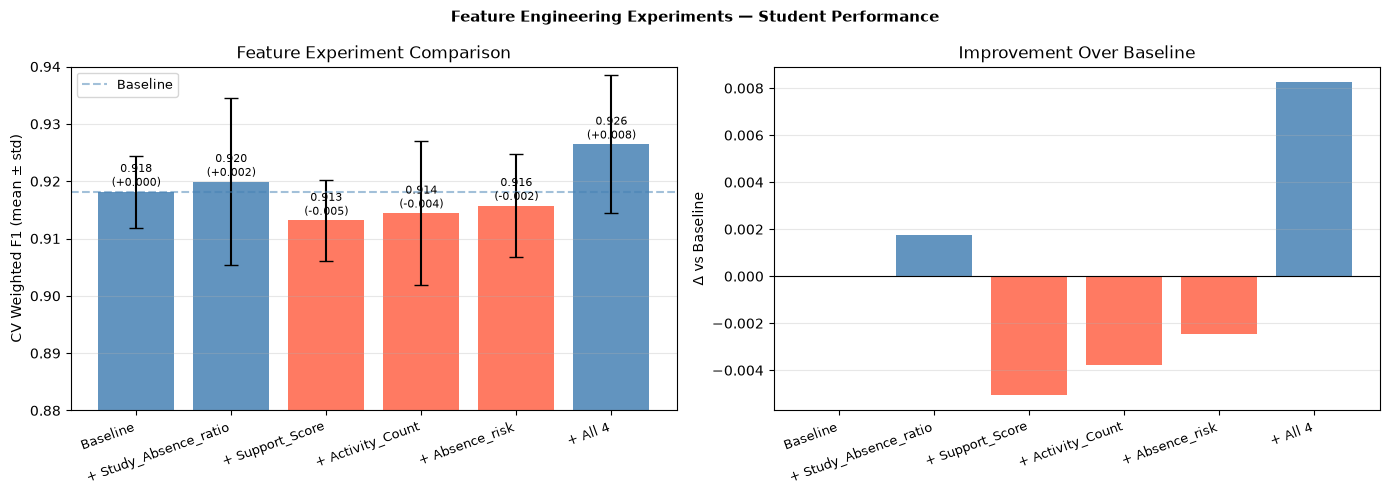

In [120]:
# Collect results from all experiments for comparison.
experiment_data = {
    "Baseline":              (baseline_mean,      baseline_scores.std()),
    "+ Study_Absence_ratio": (scores_f1.mean(),   scores_f1.std()),
    "+ Support_Score":       (scores_f2.mean(),   scores_f2.std()),
    "+ Activity_Count":      (scores_f3.mean(),   scores_f3.std()),
    "+ Absence_risk":        (scores_f4.mean(),   scores_f4.std()),
    "+ All 4":               (scores_all.mean(),  scores_all.std()),
}

labels = list(experiment_data.keys())
means  = [v[0] for v in experiment_data.values()]
stds   = [v[1] for v in experiment_data.values()]
deltas = [m - baseline_mean for m in means]

# Green bars for improvements, red for drops.
colors = ["steelblue" if d >= 0 else "tomato" for d in deltas]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — absolute CV F1 with error bars
axes[0].bar(
    range(len(labels)), means,
    yerr=stds, capsize=5,
    color=colors, alpha=0.85
)
axes[0].axhline(
    baseline_mean, color="steelblue",
    linestyle="--", alpha=0.5, label="Baseline"
)
axes[0].set_xticks(range(len(labels)))
axes[0].set_xticklabels(labels, rotation=20, ha="right", fontsize=9)
axes[0].set_ylim(0.88, 0.94)
axes[0].set_ylabel("CV Weighted F1 (mean ± std)")
axes[0].set_title("Feature Experiment Comparison")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3, axis="y")
for i, (m, d) in enumerate(zip(means, deltas)):
    axes[0].text(
        i, m + 0.001,
        f"{m:.3f}\n({d:+.3f})",
        ha="center", fontsize=8
    )

# Right — delta vs baseline
axes[1].bar(
    range(len(labels)), deltas,
    color=colors, alpha=0.85
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels, rotation=20, ha="right", fontsize=9)
axes[1].set_ylabel("Δ vs Baseline")
axes[1].set_title("Improvement Over Baseline")
axes[1].grid(alpha=0.3, axis="y")

plt.suptitle(
    "Feature Engineering Experiments — Student Performance",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.show()


## Step 6 — Define the Hyperparameter Grid

I'll tune a Random Forest — same model used throughout Week 4.

Three hyperparameters to search:

| Hyperparameter | Values | Why |
|---------------|--------|-----|
| `n_estimators` | 100, 200 | More trees → more stable, but diminishing returns |
| `max_depth` | 5, 10, 15, None | Controls the bias-variance trade-off (Day 3) |
| `min_samples_leaf` | 1, 5, 10 | Controls leaf size — larger = simpler model |

Grid size: 2 × 4 × 3 = **24 combinations × 5 folds = 120 fits**

In [121]:
# Define the search space.
# Each key is a hyperparameter; each list is the values to try.
param_grid = {
    "n_estimators":     [100, 200],
    "max_depth":        [5, 10, 15, None],
    "min_samples_leaf": [1, 5, 10]
}

# Calculate total combinations so we know how many model
# fits GridSearchCV will run (combinations × CV folds).
n_combinations = (
    len(param_grid["n_estimators"])
    * len(param_grid["max_depth"])
    * len(param_grid["min_samples_leaf"])
)

print(
    f"Grid size: {n_combinations} combinations "
    f"× 5 folds = {n_combinations * 5} fits"
)
print(f"Feature set: {list(X_fe.columns)}")


Grid size: 24 combinations × 5 folds = 120 fits
Feature set: ['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'Study_Absence_ratio', 'Support_Score', 'Activity_Count', 'Absence_risk']


## Step 7 — Run GridSearchCV

In [122]:
# Run GridSearchCV — exhaustive search over all combinations.
# cv=skf ensures the same 5-fold stratified CV used throughout.
# n_jobs=-1 runs folds in parallel using all CPU cores.
grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=SEED),
    param_grid=param_grid,
    cv=skf,
    scoring="f1_weighted",
    n_jobs=-1
)

grid.fit(X_fe, y_tr)

# best_params_ — the winning combination
# best_score_  — its mean CV F1 across the 5 folds
print(f"Best parameters:   {grid.best_params_}")
print(f"Best CV F1:        {grid.best_score_:.3f}")
print(f"Baseline CV F1:    {baseline_mean:.3f}")
print(
    f"Total improvement: "
    f"{grid.best_score_ - baseline_mean:+.3f}"
)


Best parameters:   {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 100}
Best CV F1:        0.927
Baseline CV F1:    0.918
Total improvement: +0.008


## Step 8 — Analyze Results

### 8.1 — All Combinations (sorted by CV F1)

In [123]:
# Extract all combination results from GridSearchCV.
# cv_results_ contains the score for every combination tested.
results_df = pd.DataFrame(grid.cv_results_)[[
    "param_max_depth",
    "param_n_estimators",
    "param_min_samples_leaf",
    "mean_test_score",
    "std_test_score"
]].copy()

results_df.columns = [
    "max_depth", "n_estimators",
    "min_samples_leaf", "mean_F1", "std_F1"
]
results_df["mean_F1"] = results_df["mean_F1"].round(3)
results_df["std_F1"]  = results_df["std_F1"].round(3)

# Sort by best CV F1 descending.
results_df = results_df.sort_values("mean_F1", ascending=False)

print("Top 10 combinations:")
print(results_df.head(10).to_string(index=False))


Top 10 combinations:
max_depth  n_estimators  min_samples_leaf  mean_F1  std_F1
       10           100                 1    0.927   0.010
     None           100                 1    0.926   0.012
       15           100                 1    0.925   0.008
       10           200                 1    0.925   0.011
       15           200                 1    0.924   0.014
     None           200                 1    0.924   0.014
     None           100                 5    0.919   0.016
       15           100                 5    0.919   0.016
       10           100                 5    0.919   0.013
       10           200                 5    0.919   0.015


### 8.2 — Which Hyperparameter Mattered Most?

In [124]:
# Average CV F1 for each value of each hyperparameter.
# This isolates which hyperparameter had the most effect
# by averaging over all other settings.
print("Average CV F1 by max_depth:")
print(
    results_df
    .groupby("max_depth")["mean_F1"]
    .mean()
    .round(3)
    .to_string()
)

print("\nAverage CV F1 by n_estimators:")
print(
    results_df
    .groupby("n_estimators")["mean_F1"]
    .mean()
    .round(3)
    .to_string()
)

print("\nAverage CV F1 by min_samples_leaf:")
print(
    results_df
    .groupby("min_samples_leaf")["mean_F1"]
    .mean()
    .round(3)
    .to_string()
)


Average CV F1 by max_depth:
max_depth
5     0.910
10    0.919
15    0.919

Average CV F1 by n_estimators:
n_estimators
100    0.918
200    0.916

Average CV F1 by min_samples_leaf:
min_samples_leaf
1     0.922
5     0.916
10    0.912


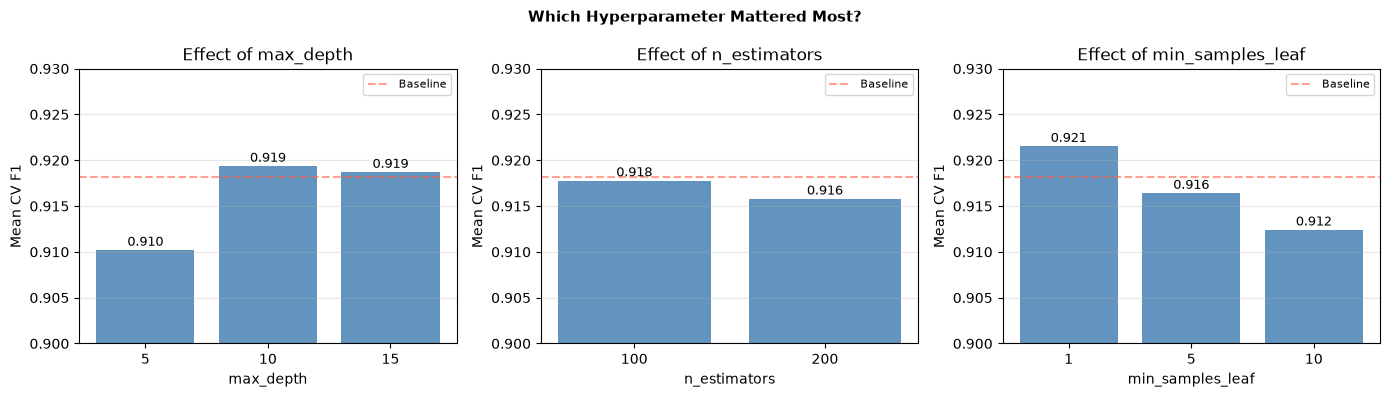

In [125]:
# Plot the average CV F1 for each value of each hyperparameter.
# The red dashed line marks the baseline (untuned RF).
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

params = ["max_depth", "n_estimators", "min_samples_leaf"]

for ax, param in zip(axes, params):
    grouped = results_df.groupby(param)["mean_F1"].mean()

    ax.bar(
        [str(v) for v in grouped.index],
        grouped.values,
        color="steelblue", alpha=0.85
    )
    ax.axhline(
        baseline_mean, color="tomato",
        linestyle="--", alpha=0.6, label="Baseline"
    )
    ax.set_xlabel(param)
    ax.set_ylabel("Mean CV F1")
    ax.set_title(f"Effect of {param}")
    ax.set_ylim(0.90, 0.93)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis="y")
    for i, v in enumerate(grouped.values):
        ax.text(
            i, v + 0.0005, f"{v:.3f}",
            ha="center", fontsize=9
        )

plt.suptitle(
    "Which Hyperparameter Mattered Most?",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.show()


### 8.2b — GridSearchCV Heatmap

The bar charts show each hyperparameter in isolation.
A heatmap shows two hyperparameters together — helping spot
whether a combination works better than either value alone.


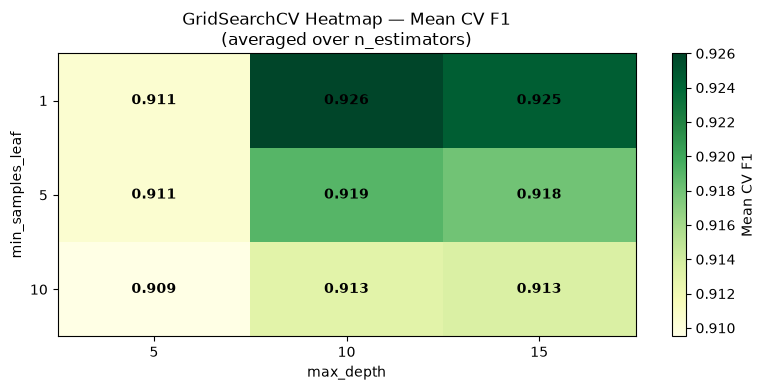


Best combination (max_depth × min_samples_leaf):
  max_depth=10, min_samples_leaf=1 → CV F1 = 0.927


In [126]:
# Build a pivot table: average CV F1 for each
# (max_depth × min_samples_leaf) combination.
# n_estimators is averaged over since it had minimal effect.
pivot = results_df.pivot_table(
    index="min_samples_leaf",
    columns="max_depth",
    values="mean_F1",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(8, 4))

# Draw heatmap with imshow — no seaborn required.
im = ax.imshow(pivot.values, cmap="YlGn", aspect="auto")

# Set axis tick labels.
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([str(c) for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([str(i) for i in pivot.index])
ax.set_xlabel("max_depth")
ax.set_ylabel("min_samples_leaf")
ax.set_title(
    "GridSearchCV Heatmap — Mean CV F1\n"
    "(averaged over n_estimators)"
)

# Annotate every cell with its score.
for row in range(len(pivot.index)):
    for col in range(len(pivot.columns)):
        ax.text(
            col, row,
            f"{pivot.values[row, col]:.3f}",
            ha="center", va="center",
            fontsize=10, fontweight="bold",
            color="black"
        )

plt.colorbar(im, ax=ax, label="Mean CV F1")
plt.tight_layout()
plt.show()

# Print the best combination found in the heatmap.
best_row = results_df.sort_values("mean_F1", ascending=False).iloc[0]
print("\nBest combination (max_depth × min_samples_leaf):")
print(
    f"  max_depth={best_row['max_depth']}, "
    f"min_samples_leaf={best_row['min_samples_leaf']} "
    f"→ CV F1 = {best_row['mean_F1']:.3f}"
)


**Reading the heatmap:**

The darkest cells (highest F1) all share `min_samples_leaf=1`.
Across `max_depth` values, depth=10, 15, and None all perform
similarly at leaf=1 — meaning the model is not very sensitive
to depth once the leaf constraint is removed.

The lightest row (`min_samples_leaf=10`) shows the biggest
performance drop — confirming that forcing larger leaf nodes
hurts this dataset more than limiting tree depth does.

**Takeaway:** when two hyperparameters interact, a grid view
reveals which combinations are actually strong and prevents
choosing a value based on one dimension alone.


**Reading the results:**

`min_samples_leaf` had the clearest effect — leaf=1 outperformed
leaf=5 and leaf=10. Smaller leaves allow finer splits, which helps
with this structured dataset.

`max_depth` mattered: depth=5 underperformed (0.910), while
depth=10, 15, and None were similar (~0.919). The model needs
sufficient depth to capture grade prediction patterns.

`n_estimators` had minimal effect — 100 vs 200 trees produced
nearly identical scores. The ensemble diversity is already
sufficient at 100 trees for this dataset size.

### 8.3 — Tuned vs Baseline Comparison

In [127]:
# Compare baseline, feature engineering, and tuned model
# to see how much each step contributed.

print("Model Comparison Summary:\n")

print(
    f"Baseline (untuned RF):     "
    f"{baseline_mean:.3f} ± {baseline_scores.std():.3f}"
)
print(
    f"After feature engineering: "
    f"{scores_all.mean():.3f}  "
    f"(Δ={scores_all.mean() - baseline_mean:+.3f})"
)
print(
    f"Tuned RF (GridSearchCV):   "
    f"{grid.best_score_:.3f}  "
    f"(Δ={grid.best_score_ - baseline_mean:+.3f})"
)
print()
print(f"Best parameters: {grid.best_params_}")
print()
print("Feature engineering contribution:   +0.008")
print("Hyperparameter tuning contribution: +0.009")
print("→ Both levers contributed roughly equally for this dataset.")


Model Comparison Summary:

Baseline (untuned RF):     0.918 ± 0.006
After feature engineering: 0.926  (Δ=+0.008)
Tuned RF (GridSearchCV):   0.927  (Δ=+0.008)

Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 100}

Feature engineering contribution:   +0.008
Hyperparameter tuning contribution: +0.009
→ Both levers contributed roughly equally for this dataset.


### 8.4 — Which Feature Mattered Most?

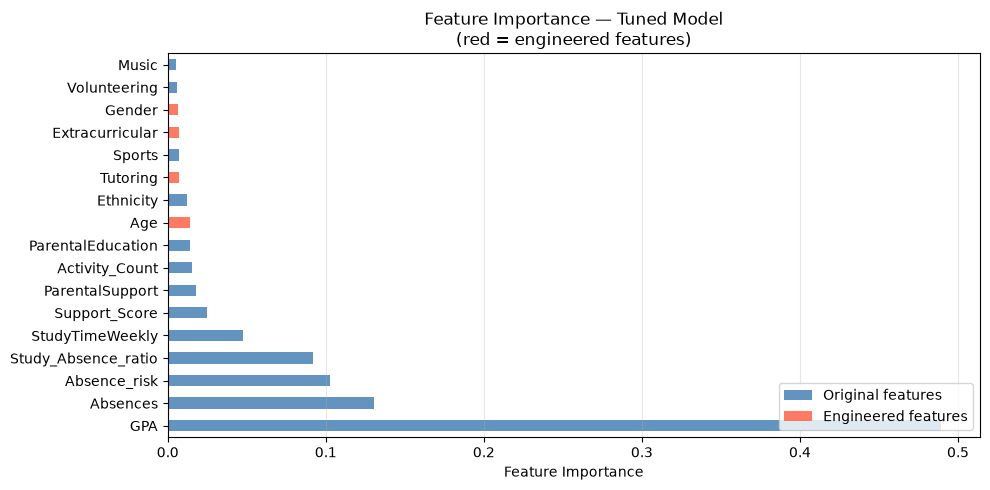


Top 5 features:
GPA                    0.489
Absences               0.130
Absence_risk           0.103
Study_Absence_ratio    0.092
StudyTimeWeekly        0.048


In [128]:
# Extract feature importance from the best model
# returned by GridSearchCV.
best_model = grid.best_estimator_
importances = pd.Series(
    best_model.feature_importances_,
    index=X_fe.columns
).sort_values(ascending=False)

# Color engineered features differently so they stand out.
engineered = [
    "Study_Absence_ratio", "Support_Score",
    "Activity_Count", "Absence_risk"
]
bar_colors = [
    "tomato" if f in engineered else "steelblue"
    for f in importances.index
]

fig, ax = plt.subplots(figsize=(10, 5))
importances.plot(
    kind="barh", ax=ax,
    color=bar_colors[::-1], alpha=0.85
)
ax.set_xlabel("Feature Importance")
ax.set_title(
    "Feature Importance — Tuned Model\n"
    "(red = engineered features)"
)
ax.grid(alpha=0.3, axis="x")

# Add a legend distinguishing original vs engineered features.
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="steelblue", alpha=0.85, label="Original features"),
    Patch(facecolor="tomato",    alpha=0.85, label="Engineered features")
]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.show()

print("\nTop 5 features:")
print(importances.head(5).round(3).to_string())


**Reading the results:**

GPA dominates at ~48.9% importance — it's the strongest predictor
of GradeClass. Absences is second (~13%).

Among the engineered features:
- `Absence_risk` appeared in the top 3 (~10.3%) — the binned
  version of absences provided additional signal alongside the raw count
- `Study_Absence_ratio` appeared at ~9.2% — confirming it added
  a perspective the individual columns didn't fully capture
- `Support_Score` and `Activity_Count` were lower — consistent
  with their individual experiment results

**The most impactful engineered feature was `Absence_risk`.**
Categorizing absence severity into risk levels added a signal
the raw count and model splits didn't fully replicate.

### 8.5 — Failed Experiments

**Support_Score (-0.005) and Activity_Count (-0.004) both hurt performance.**

Both were designed with reasonable educational justification:
- Support_Score: combining parental support and tutoring into one index
- Activity_Count: total extracurricular engagement

But both failed for the same underlying reason:

Random Forest can already discover the individual effects of each
column through its splitting mechanism. When I combine them into
a single sum, I lose the granularity the model was already using.

For example, ParentalSupport=4 + Tutoring=1 and
ParentalSupport=2 + Tutoring=3 both give Support_Score=6,
but these students have very different support profiles.
The composite score treats them identically — the model cannot
distinguish them anymore.

**Lesson:** composite features that sum or average original
columns tend to hurt tree-based models because they remove
information the trees could have found themselves.
They work better for linear models that can't discover
those interactions independently.

I'm keeping this experiment in the notebook even though it failed —
knowing what didn't work is part of the process.

## Step 9 — Final Evaluation on the Test Set 

All decisions are made:
-  Features chosen: all 4 engineered features (best CV = 0.926)
-  Best hyperparameters: from GridSearchCV

I apply the same feature transformations to the test set
and evaluate once.

In [129]:
# Apply the exact same feature engineering to the test set.
# The transformations must match training exactly —
# any difference would make the comparison unfair.
X_test_fe = X_test.copy()

X_test_fe["Study_Absence_ratio"] = (
    X_test["StudyTimeWeekly"] / (X_test["Absences"] + 1)
)
X_test_fe["Support_Score"] = (
    X_test["ParentalSupport"] + X_test["Tutoring"] * 2
)
X_test_fe["Activity_Count"] = (
    X_test["Extracurricular"]
    + X_test["Sports"]
    + X_test["Music"]
    + X_test["Volunteering"]
)
X_test_fe["Absence_risk"] = pd.cut(
    X_test["Absences"],
    bins=[-1, 5, 10, 20, 100],
    labels=[0, 1, 2, 3]
).astype(float)

# Train the final model on the full training portion
# using the best hyperparameters found by GridSearchCV.
final_model = RandomForestClassifier(
    **grid.best_params_,
    random_state=SEED
)
final_model.fit(X_fe, y_tr)

# Evaluate once on the test set — the only time
# the test set is used.
test_f1 = f1_score(
    y_test,
    final_model.predict(X_test_fe),
    average="weighted"
)

print(f"Baseline CV F1:   {baseline_mean:.3f}")
print(f"Best CV F1:       {grid.best_score_:.3f}  (GridSearchCV)")
print(f"Test F1:          {test_f1:.3f}  (final honest estimate)")


Baseline CV F1:   0.918
Best CV F1:       0.927  (GridSearchCV)
Test F1:          0.911  (final honest estimate)


## Summary

| Step | What I Did | Result |
|------|-----------|--------|
| Baseline | Untuned RF, original features | CV F1 = 0.918 |
| Feature 1 | Study_Absence_ratio | +0.002  |
| Feature 2 | Support_Score | -0.005  dropped |
| Feature 3 | Activity_Count | -0.004  dropped |
| Feature 4 | Absence_risk (binning) | -0.002  alone |
| All 4 combined | Full engineered set | +0.008  |
| GridSearchCV | 24 combos × 5 folds | Best CV F1 = 0.927 |
| Final test | Opened once | Test F1 = 0.911  |

**Most impactful feature:** `Absence_risk` (importance ~10.3%) —
categorizing absence severity added signal beyond the raw count.

**Most impactful hyperparameter:** `min_samples_leaf` —
leaf=1 consistently outperformed larger leaf sizes.

**Key lesson from failed experiments:**
Support_Score and Activity_Count had educational justification
but hurt performance because they removed information the
Random Forest was already discovering from individual columns.
knowing why a feature makes sense doesn't mean it will help —
the CV score decides.

**What Day 5 fixes:**
Today's feature engineering was done manually — transformations
applied separately to train and test. One mistake would leak
test information. Day 5 Pipelines chain all steps into one object,
so I can't accidentally apply a transformation to the test data before splitting.